In [1]:
!pip install numpy matplotlib scipy pandas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import math

In [3]:
# 1. Measuring over the first week
days = 7
# 24 hours per day
total_time = 24 * days
total_steps = 300

# Define the dosing schedules for each drug (start_hour, total_time, period)
tau_1 = np.arange(2, total_time, 24)
tau_2 = np.arange(0, total_time, 12)
tau_3 = np.arange(24, total_time, 48)

In [4]:
# Define all model parameters

u = 8.01
k_0 = math.log(2) / 2
k_1 = 0.319
k_2 = 0.184
k_3 = 0.201

k_D1 = math.log(0.5) / (-10)
k_D2 = math.log(0.5) / (-4)
k_D3 = math.log(0.5) / (-4)
P_0 = 3

In [5]:
# Defines the ODE system
def model(t, y):
    P, D_1, D_2, D_3 = y

    dD_1dt = -k_D1 * D_1
    dD_2dt = -k_D2 * D_2
    dD_3dt = -k_D3 * D_3
    dPdt = -((k_0 + k_1 * D_1 + k_2 * D_2 + k_3 * D_3) * P) + (k_0 * u)
    return [dPdt, dD_1dt, dD_2dt, dD_3dt]

In [6]:
# ORIGINAL FIRST WEEK

# Time step for simulating the time that passes
dt = 0.1
time = np.arange(0, total_time, dt)

# Lists for storing values from the iteration
T,P,DPDT, PSTAR,D1,D2,D3 = [],[],[],[],[],[],[]
y_0 = [P_0, 0, 0, 0]

for t in time:
    # Record current state of patient
    T.append(t)
    P.append(y_0[0])
    D1.append(y_0[1])
    D2.append(y_0[2])
    D3.append(y_0[3])

    # Compute and store dP/dt at the current state
    dPdt, dD_1dt, dD_2dt, dD_3dt = model(t, y_0)
    DPDT.append(dPdt)

    # Compute and store the equilibrium at the current time
    P_star = (k_0 * u) / (k_0 + k_1*y_0[1] + k_2*y_0[2] + k_3*y_0[3])
    PSTAR.append(P_star)

    
    # Advance the solution and solve the model by a small step (dt)
    sol = solve_ivp(model, t_span=[t, t + dt], y0=y_0, t_eval=[t + dt])
    y_0 = sol.y[:,0]

    # Apply the doses if the current time matches the dosing time
    if np.any(np.isclose(t, tau_1, atol=dt/2)):
        y_0[1] += 1
    if np.any(np.isclose(t, tau_2, atol=dt/2)):
        y_0[2] += 1
    if np.any(np.isclose(t, tau_3, atol=dt/2)):
        y_0[3] += 1


In [7]:
original_df = pd.DataFrame({"T": T,"P": P,"dP/dt": DPDT ,"Equilibrium": PSTAR ,"D1": D1, "D2": D2, "D3": D3})
pd.set_option('display.max_rows', 1000)
print(original_df.head(1000))

# T represents the time in hours
# 0 Is the first hour before any drug is administered
# The leftmost column represents each step we take in measuring the information. 
# Measured every (dt) of an hour, in the case of dt = 0.1, every six minutes.

        T         P     dP/dt  Equilibrium        D1        D2        D3
0     0.0  3.000000  1.736334     8.010000  0.000000  0.000000  0.000000
1     0.1  3.170659  1.093787     5.232176  0.000000  1.000000  0.000000
2     0.2  3.277692  1.047359     5.263535  0.000000  0.982821  0.000000
3     0.3  3.380226  1.003782     5.294723  0.000000  0.965936  0.000000
4     0.4  3.478536  0.962858     5.325738  0.000000  0.949342  0.000000
5     0.5  3.572880  0.924404     5.356576  0.000000  0.933033  0.000000
6     0.6  3.663494  0.888248     5.387234  0.000000  0.917004  0.000000
7     0.7  3.750601  0.854233     5.417710  0.000000  0.901250  0.000000
8     0.8  3.834407  0.822214     5.448000  0.000000  0.885768  0.000000
9     0.9  3.915105  0.792056     5.478101  0.000000  0.870551  0.000000
10    1.0  3.992876  0.763633     5.508011  0.000000  0.855595  0.000000
11    1.1  4.067886  0.736829     5.537727  0.000000  0.840896  0.000000
12    1.2  4.140292  0.711537     5.567247  0.00000

In [8]:
# Alternative model

k_4 = math.log(2 / 5.01) / -120
def model_alt(t, y):
    P, U, D_1, D_2, D_3 = y

    dD_1dt = -k_D1 * D_1
    dD_2dt = -k_D2 * D_2
    dD_3dt = -k_D3 * D_3
    du_dt = -k_4 * (U - 3)
    dP_dt = -(k_0 + k_1 * D_1 + k_2 * D_2 + k_3 * D_3) * P + k_0 * U
    return [dP_dt, du_dt, dD_1dt, dD_2dt, dD_3dt]

In [9]:
time = np.arange(0, total_time, dt)
T,P, U, PSTAR, D1,D2,D3 = [],[],[],[],[],[],[]
u_0 = u
y_0 = [P_0, u_0, 0, 0, 0]

for index, t in enumerate(time):
    T.append(t)
    P.append(y_0[0])
    U.append(y_0[1])
    D1.append(y_0[2])
    D2.append(y_0[3])
    D3.append(y_0[4])

    # Compute and store the equilibrium at the current time
    P_star = (k_0 * y_0[1]) / (k_0 + k_1*y_0[2] + k_2*y_0[3] + k_3*y_0[4])
    PSTAR.append(P_star)

    sol = solve_ivp(model_alt, t_span=[t, t + dt], y0=y_0, t_eval=[t + dt])
    
    y_0 = sol.y[:,0]

    if np.any(np.isclose(t, tau_1, atol=dt/2)):
        y_0[2] += 1
    if np.any(np.isclose(t, tau_2, atol=dt/2)):
        y_0[3] += 1
    if np.any(np.isclose(t, tau_3, atol=dt/2)):
        y_0[4] += 1

In [10]:
alternative_df = pd.DataFrame({"T": T,"P": P,"Equilibrium": PSTAR ,"U": U, "D1": D1, "D2": D2, "D3": D3})
pd.set_option('display.max_rows', 2000)
print(alternative_df.head(2000))

          T         P  Equilibrium         U        D1        D2        D3
0       0.0  3.000000     8.010000  8.010000  0.000000  0.000000  0.000000
1       0.1  3.170593     5.229673  8.006168  0.000000  1.000000  0.000000
2       0.2  3.277435     5.258500  8.002338  0.000000  0.982821  0.000000
3       0.3  3.379658     5.287129  7.998512  0.000000  0.965936  0.000000
4       0.4  3.477545     5.315557  7.994688  0.000000  0.949342  0.000000
5       0.5  3.571356     5.343781  7.990867  0.000000  0.933033  0.000000
6       0.6  3.661336     5.371799  7.987050  0.000000  0.917004  0.000000
7       0.7  3.747710     5.399607  7.983235  0.000000  0.901250  0.000000
8       0.8  3.830691     5.427203  7.979423  0.000000  0.885768  0.000000
9       0.9  3.910476     5.454584  7.975614  0.000000  0.870551  0.000000
10      1.0  3.987247     5.481748  7.971808  0.000000  0.855595  0.000000
11      1.1  4.061177     5.508694  7.968005  0.000000  0.840896  0.000000
12      1.2  4.132426    

In [15]:
# Model without non-opioid drug
dt = 0.1
time = np.arange(0, total_time, dt)

# Lists for storing values from the iteration
T,P,DPDT, PSTAR,D1,D2,D3 = [],[],[],[],[],[],[]
y_0 = [P_0, 0, 0, 0]

for t in time:
    # Record current state of patient
    T.append(t)
    P.append(y_0[0])
    D1.append(y_0[1])
    D2.append(y_0[2])
    D3.append(y_0[3])

    # Compute and store dP/dt at the current state
    dPdt, dD_1dt, dD_2dt, dD_3dt = model(t, y_0)
    DPDT.append(dPdt)

    # Compute and store the equilibrium at the current time
    P_star = (k_0 * u) / (k_0 + k_1*y_0[1] + k_2*y_0[2] + k_3*y_0[3])
    PSTAR.append(P_star)

    
    # Advance the solution and solve the model by a small step (dt)
    sol = solve_ivp(model, t_span=[t, t + dt], y0=y_0, t_eval=[t + dt])
    y_0 = sol.y[:,0]

    # Apply the doses if the current time matches the dosing time
    if np.any(np.isclose(t, tau_3, atol=dt/2)):
        y_0[3] += 1



In [18]:
with_only_non_opioid = pd.DataFrame({"T": T,"P": P,"dP/dt": DPDT ,"Equilibrium": PSTAR ,"D1": D1, "D2": D2, "D3": D3})
pd.set_option('display.max_rows', 1000)
print(with_only_non_opioid.head(1000))

# T represents the time in hours
# 0 Is the first hour before any drug is administered
# The leftmost column represents each step we take in measuring the information. 
# Measured every (dt) of an hour, in the case of dt = 0.1, every six minutes.

        T         P     dP/dt  Equilibrium   D1   D2        D3
0     0.0  3.000000  1.736334     8.010000  0.0  0.0  0.000000
1     0.1  3.170659  1.677188     8.010000  0.0  0.0  0.000000
2     0.2  3.335505  1.620057     8.010000  0.0  0.0  0.000000
3     0.3  3.494735  1.564872     8.010000  0.0  0.0  0.000000
4     0.4  3.648542  1.511566     8.010000  0.0  0.0  0.000000
5     0.5  3.797109  1.460077     8.010000  0.0  0.0  0.000000
6     0.6  3.940615  1.410341     8.010000  0.0  0.0  0.000000
7     0.7  4.079234  1.362300     8.010000  0.0  0.0  0.000000
8     0.8  4.213130  1.315895     8.010000  0.0  0.0  0.000000
9     0.9  4.342465  1.271071     8.010000  0.0  0.0  0.000000
10    1.0  4.467395  1.227773     8.010000  0.0  0.0  0.000000
11    1.1  4.588069  1.185951     8.010000  0.0  0.0  0.000000
12    1.2  4.704633  1.145553     8.010000  0.0  0.0  0.000000
13    1.3  4.817226  1.106531     8.010000  0.0  0.0  0.000000
14    1.4  4.925983  1.068839     8.010000  0.0  0.0  0

In [20]:
# Model without non-opioid drug
dt = 0.1
time = np.arange(0, total_time, dt)

# Lists for storing values from the iteration
T,P,DPDT, PSTAR,D1,D2,D3 = [],[],[],[],[],[],[]
y_0 = [P_0, 0, 0, 0]

for t in time:
    # Record current state of patient
    T.append(t)
    P.append(y_0[0])
    D1.append(y_0[1])
    D2.append(y_0[2])
    D3.append(y_0[3])

    # Compute and store dP/dt at the current state
    dPdt, dD_1dt, dD_2dt, dD_3dt = model(t, y_0)
    DPDT.append(dPdt)

    # Compute and store the equilibrium at the current time
    P_star = (k_0 * u) / (k_0 + k_1*y_0[1] + k_2*y_0[2] + k_3*y_0[3])
    PSTAR.append(P_star)

    
    # Advance the solution and solve the model by a small step (dt)
    sol = solve_ivp(model, t_span=[t, t + dt], y0=y_0, t_eval=[t + dt])
    y_0 = sol.y[:,0]

    # Apply the doses if the current time matches the dosing time
    if np.any(np.isclose(t, tau_1, atol=dt/2)):
        y_0[1] += 1
    if np.any(np.isclose(t, tau_2, atol=dt/2)):
        y_0[2] += 1


In [21]:
without_non_opioid_df = pd.DataFrame({"T": T,"P": P,"dP/dt": DPDT ,"Equilibrium": PSTAR ,"D1": D1, "D2": D2, "D3": D3})
pd.set_option('display.max_rows', 1000)
print(without_non_opioid_df.head(1000))

# T represents the time in hours
# 0 Is the first hour before any drug is administered
# The leftmost column represents each step we take in measuring the information. 
# Measured every (dt) of an hour, in the case of dt = 0.1, every six minutes.

        T         P     dP/dt  Equilibrium        D1        D2   D3
0     0.0  3.000000  1.736334     8.010000  0.000000  0.000000  0.0
1     0.1  3.170659  1.093787     5.232176  0.000000  1.000000  0.0
2     0.2  3.277692  1.047359     5.263535  0.000000  0.982821  0.0
3     0.3  3.380226  1.003782     5.294723  0.000000  0.965936  0.0
4     0.4  3.478536  0.962858     5.325738  0.000000  0.949342  0.0
5     0.5  3.572880  0.924404     5.356576  0.000000  0.933033  0.0
6     0.6  3.663494  0.888248     5.387234  0.000000  0.917004  0.0
7     0.7  3.750601  0.854233     5.417710  0.000000  0.901250  0.0
8     0.8  3.834407  0.822214     5.448000  0.000000  0.885768  0.0
9     0.9  3.915105  0.792056     5.478101  0.000000  0.870551  0.0
10    1.0  3.992876  0.763633     5.508011  0.000000  0.855595  0.0
11    1.1  4.067886  0.736829     5.537727  0.000000  0.840896  0.0
12    1.2  4.140292  0.711537     5.567247  0.000000  0.826450  0.0
13    1.3  4.210240  0.687657     5.596568  0.00

In [23]:
# Define all model parameters

u = 8.01
k_0 = math.log(2) / 2
k_1 = 0.319
k_2 = 0.184
k_3 = 0.201

k_D1 = math.log(0.5) / (-10)
k_D2 = math.log(0.5) / (-4)
k_D3 = math.log(0.5) / (-4)
P_0 = 9

In [25]:
# Model without non-opioid drug
dt = 0.1
time = np.arange(0, total_time, dt)

# Lists for storing values from the iteration
T,P,DPDT, PSTAR,D1,D2,D3 = [],[],[],[],[],[],[]
y_0 = [P_0, 0, 0, 0]

for t in time:
    # Record current state of patient
    T.append(t)
    P.append(y_0[0])
    D1.append(y_0[1])
    D2.append(y_0[2])
    D3.append(y_0[3])

    # Compute and store dP/dt at the current state
    dPdt, dD_1dt, dD_2dt, dD_3dt = model(t, y_0)
    DPDT.append(dPdt)

    # Compute and store the equilibrium at the current time
    P_star = (k_0 * u) / (k_0 + k_1*y_0[1] + k_2*y_0[2] + k_3*y_0[3])
    PSTAR.append(P_star)

    
    # Advance the solution and solve the model by a small step (dt)
    sol = solve_ivp(model, t_span=[t, t + dt], y0=y_0, t_eval=[t + dt])
    y_0 = sol.y[:,0]

    # Apply the doses if the current time matches the dosing time
    if np.any(np.isclose(t, tau_1, atol=dt/2)):
        y_0[1] += 1
    if np.any(np.isclose(t, tau_2, atol=dt/2)):
        y_0[2] += 1
    if np.any(np.isclose(t, tau_3, atol=dt/2)):
        y_0[3] += 1


In [26]:
patient_pain_starts_9_df = pd.DataFrame({"T": T,"P": P,"dP/dt": DPDT ,"Equilibrium": PSTAR ,"D1": D1, "D2": D2, "D3": D3})
pd.set_option('display.max_rows', 1000)
print(patient_pain_starts_9_df.head(1000))

# T represents the time in hours
# 0 Is the first hour before any drug is administered
# The leftmost column represents each step we take in measuring the information. 
# Measured every (dt) of an hour, in the case of dt = 0.1, every six minutes.

        T         P     dP/dt  Equilibrium        D1        D2        D3
0     0.0  9.000000 -0.343108     8.010000  0.000000  0.000000  0.000000
1     0.1  8.966277 -1.981215     5.232176  0.000000  1.000000  0.000000
2     0.2  8.774696 -1.851831     5.263535  0.000000  0.982821  0.000000
3     0.3  8.595636 -1.730688     5.294723  0.000000  0.965936  0.000000
4     0.4  8.428302 -1.617220     5.325738  0.000000  0.949342  0.000000
5     0.5  8.271954 -1.510899     5.356576  0.000000  0.933033  0.000000
6     0.6  8.125901 -1.411241     5.387234  0.000000  0.917004  0.000000
7     0.7  7.989499 -1.317794     5.417710  0.000000  0.901250  0.000000
8     0.8  7.862149 -1.230141     5.448000  0.000000  0.885768  0.000000
9     0.9  7.743290 -1.147896     5.478101  0.000000  0.870551  0.000000
10    1.0  7.632401 -1.070699     5.508011  0.000000  0.855595  0.000000
11    1.1  7.528993 -0.998219     5.537727  0.000000  0.840896  0.000000
12    1.2  7.432611 -0.930146     5.567247  0.00000

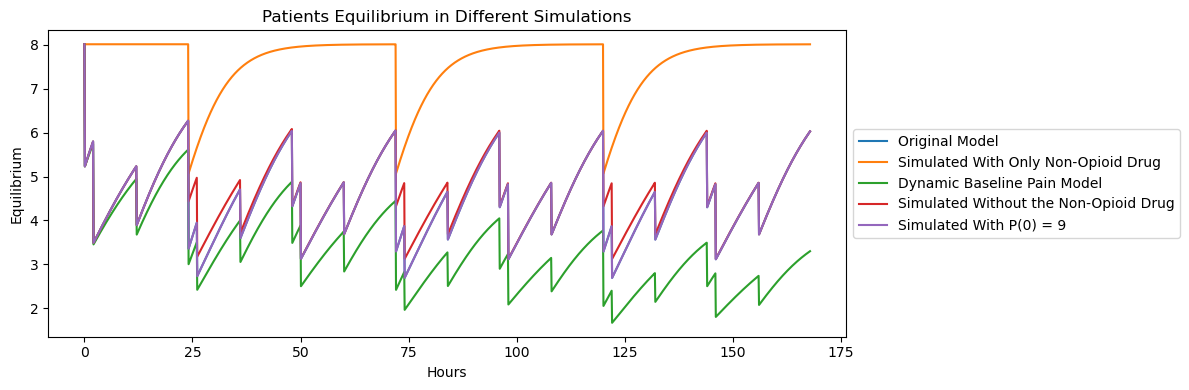

In [34]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_title("Patients Equilibrium in Different Simulations")
ax.set_xlabel("Hours")
ax.set_ylabel("Equilibrium")


ax.plot(original_df["T"], original_df["Equilibrium"], label="Original Model")
ax.plot(with_only_non_opioid["T"], with_only_non_opioid["Equilibrium"], label="Simulated With Only Non-Opioid Drug")
ax.plot(alternative_df["T"], alternative_df["Equilibrium"], label="Dynamic Baseline Pain Model")
ax.plot(without_non_opioid_df["T"], without_non_opioid_df["Equilibrium"], label="Simulated Without the Non-Opioid Drug")
ax.plot(patient_pain_starts_9_df["T"], patient_pain_starts_9_df["Equilibrium"], label="Simulated With P(0) = 9")

ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()
 

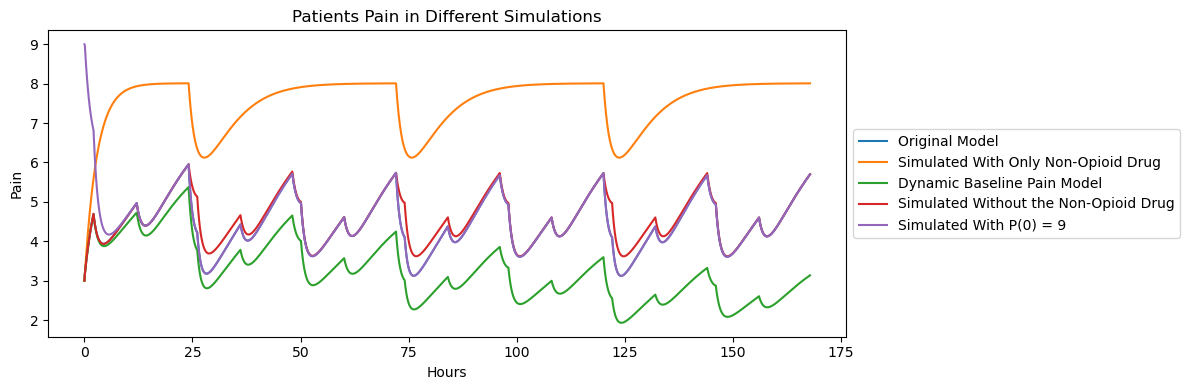

In [35]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_title("Patients Pain in Different Simulations")
ax.set_xlabel("Hours")
ax.set_ylabel("Pain")

ax.plot(original_df["T"], original_df["P"], label="Original Model")
ax.plot(with_only_non_opioid["T"], with_only_non_opioid["P"], label="Simulated With Only Non-Opioid Drug")
ax.plot(alternative_df["T"], alternative_df["P"], label="Dynamic Baseline Pain Model")
ax.plot(without_non_opioid_df["T"], without_non_opioid_df["P"], label="Simulated Without the Non-Opioid Drug")
ax.plot(patient_pain_starts_9_df["T"], patient_pain_starts_9_df["P"], label="Simulated With P(0) = 9")

ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()
